In [69]:
#!/usr/bin/env python
# coding: utf-8

import hues
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from tools import downsample_block, ATTACK_EVENTS_WADI as ATTACK_EVENTS

In [70]:
df = pd.read_pickle('../../Data/WADI/data.pkl')

hues.info(df.shape)

df.head()

20:17:59 - INFO - (1382401, 101)


,Timestamp,Train,1_AIT_001_PV,1_AIT_002_PV,1_AIT_003_PV,1_AIT_004_PV,1_AIT_005_PV,1_FIT_001_PV,1_LT_001_PV,1_MV_001_STATUS,...,3_AIT_001_PV,3_AIT_002_PV,3_AIT_003_PV,3_AIT_004_PV,3_AIT_005_PV,3_FIT_001_PV,3_LT_001_PV,LEAK_DIFF_PRESSURE,TOTAL_CONS_REQUIRED_FLOW,Attack
0,2017-09-25 18:00:00,1,171.155,0.619473,11.5759,504.645,0.318319,0.001157,47.8911,1,...,0.0,0.0,1.18417,618.079,0.375448,0.001268,64.3425,67.9651,0.68,0
1,2017-09-25 18:00:01,1,171.155,0.619473,11.5759,504.645,0.318319,0.001157,47.8911,1,...,0.0,0.0,1.18417,618.079,0.375448,0.001268,64.3425,67.9651,0.68,0
2,2017-09-25 18:00:02,1,171.155,0.619473,11.5759,504.645,0.318319,0.001157,47.8911,1,...,0.0,0.0,1.18417,618.079,0.375448,0.001268,64.3425,67.9651,0.68,0
3,2017-09-25 18:00:03,1,171.155,0.607477,11.5725,504.673,0.318438,0.001207,47.7503,1,...,0.0,0.0,1.18005,618.107,0.375398,0.001133,64.3199,67.1948,0.68,0
4,2017-09-25 18:00:04,1,171.155,0.607477,11.5725,504.673,0.318438,0.001207,47.7503,1,...,0.0,0.0,1.18005,618.107,0.375398,0.001133,64.3199,67.1948,0.68,0


In [71]:
# =========================
# 3) 列类型划分：特征列 / 标签列
# =========================
label_cols = ["Timestamp", "Train", "Attack"]

# 特征列：除 Timestamp/Train/Attack 外的所有列
feature_cols = [c for c in df.columns if c not in label_cols]

# 状态列（离散/开关/阀门等）：WADI 通常以 STATUS 命名
status_cols = [c for c in feature_cols if "STATUS" in c.upper()]

# 连续列：其余都按连续量处理（PV、流量、压力等）
cont_cols = [c for c in feature_cols if c not in status_cols]

In [72]:
df_test = df[df["Train"] == 0].copy()

hues.info(("Test raw:", df_test.shape))

# 只保留必要列（仍保留 Timestamp/Train/Attack，便于下采样聚合）
df_test = df_test[["Timestamp", "Train", "Attack"] + feature_cols]

20:18:00 - INFO - ('Test raw:', (172801, 101))


In [73]:
# 下采样尺度列表
DOWNSAMPLE_LIST = [10, 30, 60, 120]

attack_colors = ['#21a675', '#4a4266', '#4b5cc4', '#f2be45', '#ed5736', '#392f41', '#ff8936', '#30dff3', '#8c4356',
                 '#b35c44', '#a98175', '#fff143', '#9b4400', '#00e500', '#f00056', '#e29c45', '#f20c00']

In [74]:
df_test_dict = {}  # key: downsample_sec, value: df_test

# 原始（不下采样）
df_test_dict["orig"] = df[df["Train"] == 0].copy()

# 不同下采样尺度
for sec in DOWNSAMPLE_LIST:
    df_test_dict[sec] = downsample_block(
        df[df["Train"] == 0].copy(),
        cont_cols,
        status_cols,
        sec
    )

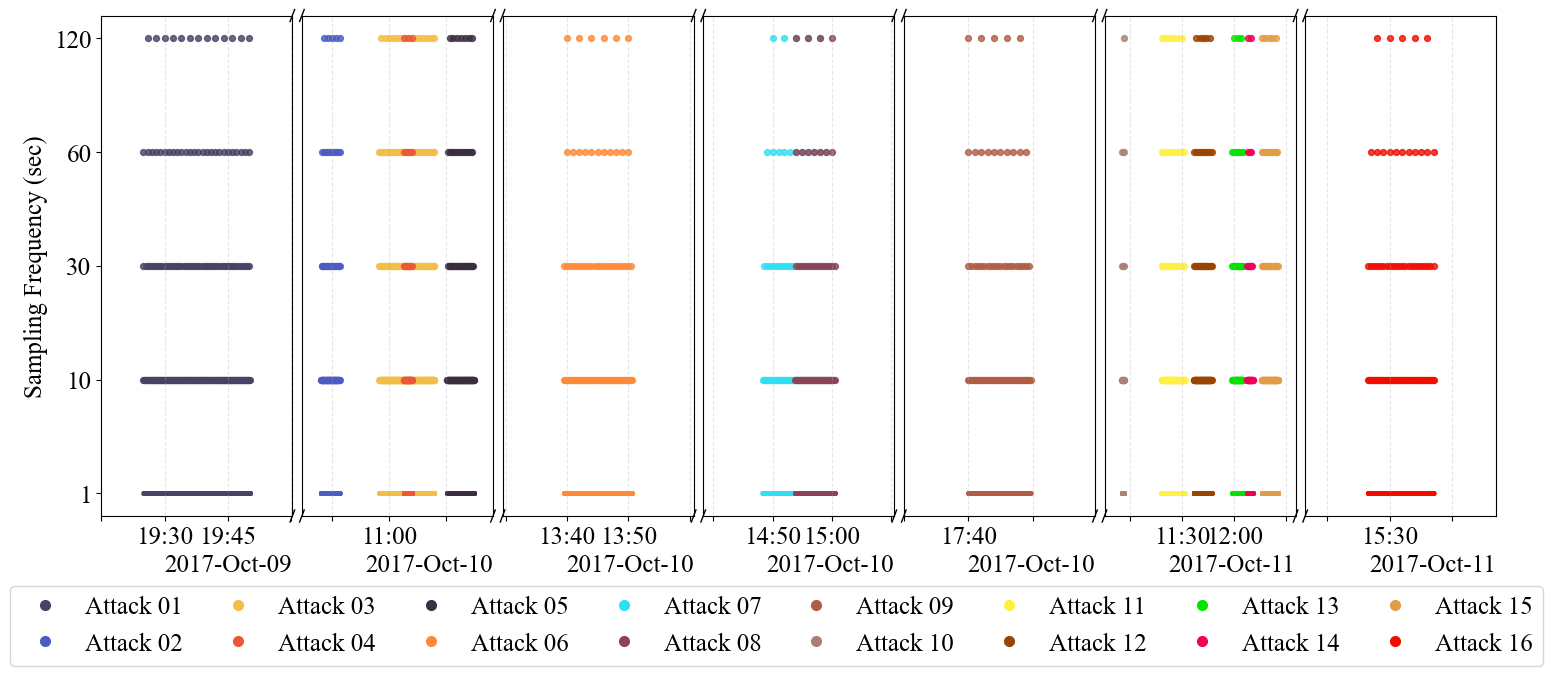

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# =========================
# 0) Matplotlib 全局字体设置（你给的 그대로）
# =========================
plt.rcParams.update({
    "font.size": 18,
    "font.family": ["Times New Roman", "SimSun"],
    # ===== 数学公式（mathtext） =====
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',  # 正体
    'mathtext.it': 'Times New Roman:italic',  # 斜体
    'mathtext.bf': 'Times New Roman:bold',  # 粗体
})

# =========================
# 2) 断轴（压缩无攻击空窗）参数
# =========================
PAD_BEFORE = timedelta(minutes=10)  # 每个攻击段前额外显示的正常区间
PAD_AFTER = timedelta(minutes=10)  # 每个攻击段后额外显示的正常区间
MERGE_GAP = timedelta(minutes=5)  # 相邻显示段之间小于该间隔则合并，避免太碎

# =========================
# 3) 生成要显示的时间段 segments（并合并重叠/相邻段）
# =========================
segments = []
for (start, end, _) in ATTACK_EVENTS:
    segments.append((start - PAD_BEFORE, end + PAD_AFTER))

segments = sorted(segments, key=lambda x: x[0])

merged = []
for s, e in segments:
    if not merged:
        merged.append([s, e])
    else:
        ps, pe = merged[-1]
        if s <= pe + MERGE_GAP:
            merged[-1][1] = max(pe, e)
        else:
            merged.append([s, e])

segments = [(s, e) for s, e in merged]

# =========================
# 4) y 轴位置映射（与你原来一致）
# =========================
y_levels = {"orig": 0}
for i, sec in enumerate(DOWNSAMPLE_LIST, 1):
    y_levels[sec] = i

yticks = list(y_levels.values())
ylabels = ["1"] + [f"{sec}" for sec in DOWNSAMPLE_LIST]

# =========================
# 5) 建图：每个 segment 一个子图（共享 y 轴）=> 实现断轴效果
# =========================
nseg = len(segments)
fig, axes = plt.subplots(
    1, nseg,
    figsize=(18, 2.5 + 0.8 * (len(DOWNSAMPLE_LIST) + 1)),
    sharey=True,
    gridspec_kw={"wspace": 0.05}
)

if nseg == 1:
    axes = [axes]

# =========================
# 6) 绘制：逐事件、逐尺度、逐 segment 绘点
# =========================
legend_handles = []
legend_labels = []
for ax, (seg_start, seg_end) in zip(axes, segments):
    for attack_id, (start, end, _) in enumerate(ATTACK_EVENTS, 1):

        # 若该攻击事件与当前 segment 无交集，跳过
        if end < seg_start or start > seg_end:
            continue

        for key, y in y_levels.items():
            _df = df_test_dict[key]

            mask = (
                    (_df["Attack"] == 1) &
                    (_df["Timestamp"] >= max(start, seg_start)) &
                    (_df["Timestamp"] <= min(end, seg_end))
            )

            times = _df.loc[mask, "Timestamp"]
            if len(times) == 0:
                continue

            ax.scatter(
                times,
                np.full(len(times), y),
                s=18 if key != "orig" else 6,
                color=attack_colors[attack_id],
                alpha=0.8,
            )

        legend_handles.append(
            Line2D(
                [0], [0],
                marker='o',
                linestyle='None',
                markersize=7,
                markerfacecolor=attack_colors[attack_id],
                markeredgecolor=attack_colors[attack_id],
                # alpha=0.9
            )
        )
        legend_labels.append(f"Attack {attack_id:02d}")

    ax.set_xlim(seg_start, seg_end)

    # 控制每个子图的 x 轴时间刻度（关键）
    locator = mdates.AutoDateLocator(minticks=2, maxticks=5)
    formatter = mdates.ConciseDateFormatter(locator)

    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    # 获取当前刻度与标签
    ticks = ax.get_xticks()
    labels = ax.get_xticklabels()

    # 第一个子图：隐藏最右侧刻度
    if i == 0:
        if len(labels) > 0:
            labels[-1].set_visible(False)

    # 最后一个子图：隐藏最左侧刻度
    elif i == len(axes) - 1:
        if len(labels) > 0:
            labels[0].set_visible(False)

    # 中间子图：隐藏首尾刻度
    else:
        if len(labels) > 1:
            labels[0].set_visible(False)
            labels[-1].set_visible(False)

    ax.grid(axis="x", linestyle="--", alpha=0.3)

# =========================
# 7) y 轴标签只在最左侧显示
# =========================
axes[0].set_yticks(yticks)
axes[0].set_yticklabels(ylabels)
axes[0].set_ylabel('Sampling Frequency (sec)')

for ax in axes[1:]:
    ax.tick_params(axis="y", left=False, labelleft=False)

# =========================
# 8) 断轴标记：相邻子图之间画 “//”
# =========================
d = 0.012
for i in range(nseg - 1):
    ax1, ax2 = axes[i], axes[i + 1]

    # 右侧子图边界（ax1 的右边）
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    # 左侧子图边界（ax2 的左边）
    kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=1)
    ax2.plot((-d, +d), (-d, +d), **kwargs)
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(.5, -.14),  # 越接近 0 越靠下
    ncol=8,  # 16 个事件：4 列比较舒服；你也可用 5/6
    # frameon=False,
    handletextpad=0.6,
    columnspacing=1.2
)

plt.show()